# Inference with the PPAN Model
This notebook goes through the steps required to perform inference with 
the PPAN Model.
The process involves a few steps:

1. Scanning a directory for all videos
2. Iteratively Loading and Pre-processing all videos
3. Getting predictions from the model
4. Performing post-processing on the model predictions
5. Generating a nice MIDI file

Luckily, the PPAN python package contains many helper functions we can 
utilize!

In [1]:
# Let's get imports out of the way first
import os
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import torch
from torch import no_grad, squeeze
import torchvision
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms import v2
from transformers import (
    VideoMAEImageProcessor
)
from accelerate.utils import write_basic_config

from ppan.config import pretrained_model
from ppan.dataset import PPAnEvalDataset
from ppan.evaluate_model import (
    eval_loop, 
    calc_time, 
    final_pred_to_onset_array,
    save_to_midi
)
from ultralytics import YOLO
from tqdm import tqdm
import pickle

# Useful for typing
PathLike = str | os.PathLike

## Parameters
Make sure that all videos you are using are the same framerate and that 
the framerate is a multiple of 30. 
They should also all be in a format supported by the Nvidia DALI library.


In [2]:
# Dataset settings
## Folder containing all videos.
video_dir: PathLike = None
## Whether to rotate the video 180 degrees.
rotate_180: Optional[bool] = None

# Output settings
## Directory to output generated MIDI files to. 
midi_output_dir: Optional[PathLike] = None
## Pickle file to store model preds.
cache_output_file: Optional[PathLike] = None
## Whether to recalculate the model preds even if the cache file exists.
recalc_preds: Optional[bool] = True
## Whether to calculate the bounding boxes and use them.
calculate_bbs: Optional[bool] = True

# Model settings
ppan_model_checkpoint: PathLike = None
yolo_model_checkpoint: PathLike = None
batch_size: Optional[int] = None

# Settings for model output post-processing
threshold: Optional[float] = None
gaussian_sigma: Optional[float] = None

In [3]:
# Check everything is set correctly and do some initial setup.
required_vars = [video_dir, ppan_model_checkpoint, yolo_model_checkpoint]
if None in required_vars:
    raise AttributeError("Please set all required variables!!")

# Set defaults if unset:
if cache_output_file is None:
    cache_output_file = "model_preds.pkl"
if midi_output_dir is None:
    midi_output_dir = "./preds_midi"
if recalc_preds is None:
    recalc_preds = False
if threshold is None:
    threshold = 0.5
if gaussian_sigma is None:
    gaussian_sigma = 1
if calculate_bbs is None:
    calculate_bbs = True
if rotate_180 is None:
    rotate_180 = False
if batch_size is None:
    batch_size = 1
    
# If the MIDI output directory doesn't exist we create it:
midi_output_dir = Path(midi_output_dir)
midi_output_dir.mkdir(exist_ok=True)

# Since parts of this notebook use accelerate we make a basic config.
write_basic_config()


def show(imgs):
    """
    Helper function for plotting tensors. See:
    https://pytorch.org/vision/main/auto_examples/others/plot_visualization_utils.html#visualizing-bounding-boxes
    """
    if not isinstance(imgs, list):
        imgs = [imgs]
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, 
                            figsize=(len(imgs)*5, 6))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = v2.functional.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

Configuration already exists at /home/chromeilion/.cache/huggingface/accelerate/default_config.yaml, will not override. Run `accelerate config` manually or pass a different `save_location`.


## Data Loading
Let's write a helper function for loading our data.
Because we'd like to use the PPAnEvalDataset object, we need to make sure 
our data is in the correct format.

In [4]:
def prepare_data(data_dir: PathLike, rotate: bool):
    """
    Simple sample loading script. Feel free to modify this for your 
    needs.
    
    Parameters
    ----------
    data_dir : PathLike
        Folder containing videos in a format supported by Nvidia DALI.
    rotate : bool

    Returns
    -------
    samples : ppan.dataset.SAMPLE_TYPE
        [midi_path, flac_path, video_path, bounding_box, whether to rotate 180, random_resize]
    """
    videos = os.listdir(data_dir)
    videos = [os.path.join(data_dir, i) for i in videos]
    none = [None for _ in videos]
    rotate = [rotate for _ in videos]
    false = [False for _ in videos]
    return list(zip(none, none, videos, none, rotate, false))

### Bounding Box Detection
As a part of the pre-processing stage we also want to detect bounding 
boxes.
This could be done during the main prediction loop (right before we pass 
the image to the main ppan model), but it's more convenient to do it here.
In the case that the piano moves around this method is not ideal.

In [5]:
def calculate_bounding_boxes(samples, yolo_model_checkpoint):
    """
    Get bounding box predictions for a list of samples.
    Utilizes the Ultralytics package. 

    Parameters
    ----------
    samples : list[ppan.dataset.SAMPLE_TYPE]
    yolo_model_checkpoint : PathLike
    
    Returns
    -------
    samples : ppan.dataset.SAMPLE_TYPE
        The same samples as passed in but with bounding boxes added.
    """
    # Load the model
    model = YOLO(yolo_model_checkpoint)
    
    new_samples = []
    for sample in tqdm(samples):
        sample_preds = []
        video = sample[2]
        pred = model.predict(source=str(video), stream=True, 
                             verbose=False, vid_stride=15)
        # Get predictions over the first 10 seconds.
        [sample_preds.append(next(pred)) for _ in range(2*10)]

        filtered_session_preds = [
            i for i in sample_preds if i.boxes.conf.shape[0] > 0
        ]
        best_pred = max(filtered_session_preds, key=lambda x: x.boxes.conf[0])
        bb_meta = squeeze(best_pred.boxes.xyxy).cpu()
        bb = (round(float(bb_meta[0])), round(float(bb_meta[2])),
              round(float(bb_meta[1])), round(float(bb_meta[3])))
        new_sample = [i for i in sample]
        new_sample[3] = bb
        new_samples.append(new_sample)
    return new_samples 

Now let's use our helper functions and create an instance of the dataset.

In [6]:
if not Path(cache_output_file).exists() or recalc_preds:
    # Load all our samples
    samples = prepare_data(
        data_dir=video_dir, 
        rotate=rotate_180
    )
    if calculate_bbs:
        # Calculate all bounding boxes
        samples = calculate_bounding_boxes(
            samples=samples, 
            yolo_model_checkpoint=yolo_model_checkpoint
        )
    # Load our dataset and pre-trained model processor
    processor = VideoMAEImageProcessor.from_pretrained(
        pretrained_model
    )
    dataset = PPAnEvalDataset(
        datasets=samples,
        video_transform=processor,
        batch_size=batch_size
    )

100%|██████████| 2/2 [00:04<00:00,  2.26s/it]


/home/chromeilion/Code/Uni/uni2023w/rach3_continued/ppan/.venv/lib/python3.11/site-packages/torchvision/io/video_reader.py:233: UserWarning: Accurate seek is not implemented for pyav backend
  warnings.warn("Accurate seek is not implemented for pyav backend")


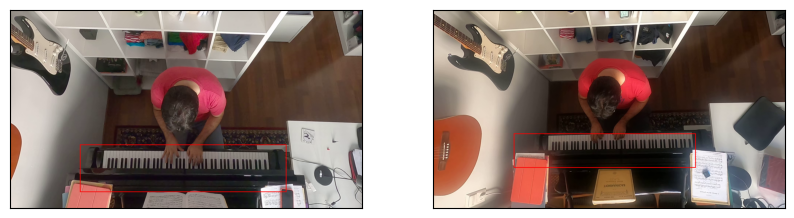

In [7]:
def visualize_bbs(samples):
    # Visualize up to 4 videos.
    no_plots = min(len(samples), 4)
    results = []
    for idx, sample in enumerate(samples[:no_plots]):
        stream = "video"
        video = torchvision.io.VideoReader(sample[2], stream)
        halfway = video.get_metadata()["video"]["duration"][0] / 2
        frame = next(video.seek(halfway))['data'].detach()
        bb = sample[3]
        bb = torch.tensor([[bb[0], bb[2], bb[1], bb[3]]])
        results.append(
            draw_bounding_boxes(
                frame, 
                boxes=bb, 
                width=4, 
                colors="red"
            )
        )
    show(results)
    
# Let's also visualize the new bounding boxes:
if calculate_bbs:
    visualize_bbs(samples=samples)



## Inference
With the dataset loaded, we can now perform inference using the 
trained model.
For this we utilize the provided helper function from PPAN.

In [ ]:
if not Path(cache_output_file).exists() or recalc_preds:
    # Use no_grad for better performance.
    with no_grad():
        preds = eval_loop(
            dataset=dataset,
            model_checkpoint=ppan_model_checkpoint
        )
    # Save our outputs so that we can rerun this notebook with the 
    # cached outputs.
    with open(cache_output_file, "wb") as f:
        pickle.dump(obj=preds, file=f)
else:
    # Load our already calculated model predictions.
    with open(cache_output_file, "rb") as f:
        preds = pickle.load(f)

 73%|███████▎  | 5095/7005 [16:18<05:44,  5.55it/s]

## Post-Processing
Although we have model predictions, there's still work to do to make 
them usable.
Let's define a helper function for post-processing the model outputs.

In [ ]:
def do_postprocessing(video_preds, threshold, gaussian_sigma):
    """
    Perform post-processing on the PPAN model outputs.
    This function utilizes the provided functions from PPAN.
    
    Returns
    -------
    onset_array : npt.NDArray[int]
        A regular onset array, similar to a pianoroll.
    """
    final_pred = calc_time(video_preds)
    onset_array = final_pred_to_onset_array(
        final_pred, 
        threshold,
        gaussian_sigma
    )
    # Multiply the onset array by 100 to make the notes louder.
    onset_array = onset_array.astype(int) * 100
    return onset_array

## Saving to MIDI
Let's also define a helper function that saves our predictions to a MIDI 
file.

In [ ]:
def save_midi(onset_array: npt.NDArray[int], 
                 video_path: PathLike, 
                 midi_output_dir: Path) -> None:
    """
    Save an onset_array to a MIDI file. 
    Utilizes a helper function from PPAN.
    
    Parameters
    ----------
    video_path : PathLike
    midi_output_dir : Path
    """
    # Let's name the MIDI file after the input video.
    vid_path = Path(video_path)
    mid_output = midi_output_dir/(vid_path.stem + ".mid")
    save_to_midi(onset_array, str(mid_output))

## Performing Post-Processing and Saving MIDI's
With our helper functions we can iterate through our model predictions 
and apply post-processing as well as save them. 

In [ ]:
# Iterate through all videos and their predictions.
for vid_path, vid_preds in preds.items():
    onset_array = do_postprocessing(
        video_preds=vid_preds,
        threshold=threshold,
        gaussian_sigma=gaussian_sigma
    )
    save_midi(
        onset_array=onset_array,
        video_path=vid_path,
        midi_output_dir=midi_output_dir
    )

## Conclusion
With that we're done! 
You can listen to your shiny new MIDI files in any way you'd like.
One can see that PPAN's helper functions make inference much easier.
The only thing that the may need to change is the way samples are 
loaded.